In [1]:
import keras
import pickle
import os

from mlflow.metrics import f1_score

from TP_final.dataloading import load_dataloaders
from architectures import VGG_TF  # If needed for model redefinition (custom objects)

models = {}       # Dictionary to hold models
histories = {}    # Dictionary to hold histories

# Directory containing your models
model_dir = '.'  # or replace with your path like 'models/'

for filename in os.listdir(model_dir):
    if filename.endswith('.keras'):
        model_name = os.path.splitext(filename)[0]  # Remove .keras extension
        model_path = os.path.join(model_dir, filename)

        print(f"Loading model: {model_name} from {model_path}")
        models[model_name] = keras.models.load_model(model_path)

        # Try to load the corresponding history .pkl file
        history_filename = model_name + '_history.pkl'
        history_path = os.path.join(model_dir, history_filename)

        if os.path.exists(history_path):
            with open(history_path, 'rb') as f:
                histories[model_name] = pickle.load(f)
            print(f"Loaded training history for {model_name}")
        else:
            histories[model_name] = None
            print(f"No history found for {model_name}")


2025-04-19 16:06:41.646264: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-19 16:06:41.768001: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745089601.815899  571453 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745089601.829687  571453 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1745089601.931632  571453 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

✅ Se han cargado las variables de configuración desde 'constants.yaml'
 - ROOT_DIR: /home/juan/.cache/kagglehub/datasets/abdallahalidev/plantvillage-dataset/versions/3/plantvillage dataset/color
 - DATASET_PATH: /home/juan/.cache/kagglehub/datasets/abdallahalidev/plantvillage-dataset/versions/3
 - SPLITTED_PATH: /home/juan/.cache/kagglehub/datasets/abdallahalidev/plantvillage-dataset/splitted/
Loading model: best_model from ./best_model.keras


I0000 00:00:1745089605.221853  571453 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6103 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


No history found for best_model
Loading model: model_vgg_4 from ./model_vgg_4.keras
Loaded training history for model_vgg_4
Loading model: model_vgg_5 from ./model_vgg_5.keras
Loaded training history for model_vgg_5


In [2]:
models

{'model_vgg': <VGG_TF name=vgg_tf_1, built=True>,
 'model_vgg_5': <VGG_TF name=vgg_tf_3, built=True>}

In [3]:
histories

{'model_vgg': {'f1_score': [<tf.Tensor: shape=(38,), dtype=float32, numpy=
   array([0.7112024 , 0.82591087, 0.69801974, 0.8526836 , 0.9047224 ,
          0.8821788 , 0.88286966, 0.6592592 , 0.94835675, 0.7891332 ,
          0.9614561 , 0.8672286 , 0.8976307 , 0.9019152 , 0.82407403,
          0.97456753, 0.8885307 , 0.738574  , 0.784683  , 0.8649107 ,
          0.83878934, 0.75160044, 0.5814977 , 0.8445229 , 0.95134735,
          0.94326717, 0.87458   , 0.8363636 , 0.82318664, 0.52742887,
          0.74195665, 0.7156084 , 0.7100384 , 0.77440816, 0.6453333 ,
          0.9382458 , 0.6853146 , 0.84656894], dtype=float32)>],
  'loss': [0.5556297898292542],
  'val_f1_score': [<tf.Tensor: shape=(38,), dtype=float32, numpy=
   array([0.9032257 , 0.9761904 , 0.9320388 , 0.9515418 , 0.9832215 ,
          0.9805825 , 0.97633135, 0.8453608 , 0.99163175, 0.91811407,
          0.9978494 , 0.9223743 , 0.9470085 , 0.97716886, 0.95857984,
          0.9927928 , 0.9688506 , 0.9411765 , 0.94376516, 0.94

In [2]:
compiled_metrics_names = ['f1_score', 'accuracy']
metrics = {'f1_score':f1_score,
           'accuracy':keras.metrics.categorical_accuracy}


In [3]:
from TP_final.model_evaluation import evaluate_multiple_models, plot_model_comparison

vgg_aux =  VGG_TF(38)
preprocess_function_vgg = vgg_aux.preprocess

dataloaders,class_names_train = load_dataloaders(preprocess_function_vgg)



Cargando datasets desde el directorio…

Cargando dataset de entrenamiento desde:
 > /home/juan/.cache/kagglehub/datasets/abdallahalidev/plantvillage-dataset/splitted/train/
Found 43444 files belonging to 38 classes.
✅ Dataset cargado exitosamente.

Cargando dataset de test desde:
 > /home/juan/.cache/kagglehub/datasets/abdallahalidev/plantvillage-dataset/splitted/test/
Found 10861 files belonging to 38 classes.
✅ Dataset cargado exitosamente.



In [4]:
dataloaders

{'train': <_MapDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 38), dtype=tf.float32, name=None))>,
 'test': <_MapDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 38), dtype=tf.float32, name=None))>,
 'valid': ''}

In [5]:
dataloader = dataloaders['test']

results = evaluate_multiple_models(models, dataloader, compiled_metrics_names, metrics)


Evaluating model: best_model


I0000 00:00:1745089757.801112  571555 service.cc:152] XLA service 0x7a14f400e140 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1745089757.801201  571555 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4070 Laptop GPU, Compute Capability 8.9
2025-04-19 16:09:17.872298: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1745089758.043369  571555 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-04-19 16:09:18.747005: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_277_0', 48 bytes spill stores, 48 bytes spill loads

2025-04-19 16:09:18.805232: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusi

Model metrics names: ['loss', 'compile_metrics']
compiled metrics: '['f1_score', 'accuracy']'...
compiled metrics: '['f1_score', 'accuracy']'...

Evaluating model: model_vgg_4
Model metrics names: ['loss', 'compile_metrics']
compiled metrics: '['f1_score', 'accuracy']'...
compiled metrics: '['f1_score', 'accuracy']'...

Evaluating model: model_vgg_5
Model metrics names: ['loss', 'compile_metrics']
compiled metrics: '['f1_score', 'accuracy']'...
compiled metrics: '['f1_score', 'accuracy']'...


In [8]:
import pandas as pd

df = pd.DataFrame.from_dict(results, orient='index').reset_index()
df.rename(columns={'index': 'model_name'}, inplace=True)

# Average f1_score values if they are Tensors, arrays or lists
df['f1_score'] = df['f1_score'].apply(
    lambda x: np.mean(x.numpy()) if hasattr(x, 'numpy') else np.mean(x) if isinstance(x, (list, np.ndarray)) else x
)

In [11]:
df

,model_name,f1_score,accuracy
0,best_model,0.941292,0.957002
1,model_vgg_4,0.941292,0.957002
2,model_vgg_5,0.931213,0.950005


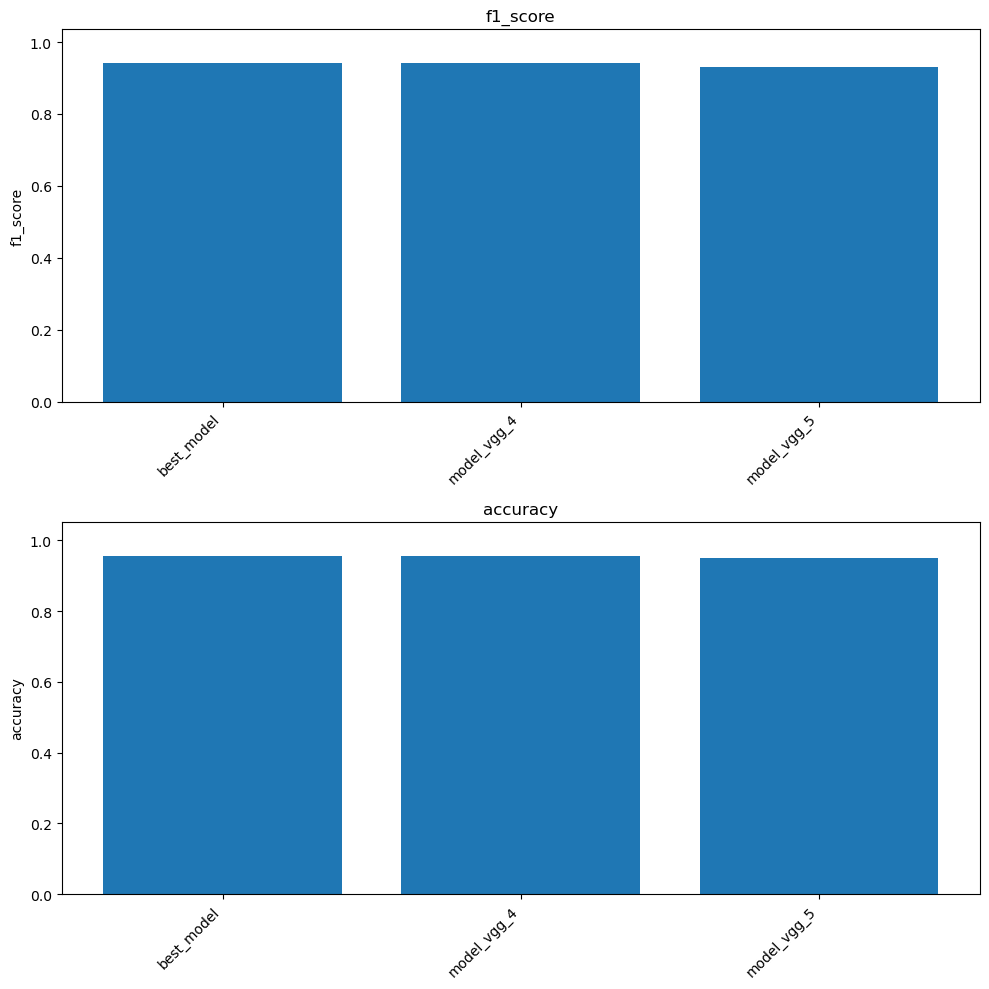

In [15]:
from TP_final.model_evaluation import plot_model_comparison 
plot_model_comparison(df, ['f1_score','accuracy'])